# EDA and Early Preprocessing Assignments

**Name:** Hubert Cendana

**NIM:** 245150207111049

---

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

This notebook contains assignments focused on **Exploratory Data Analysis (EDA)** and **Early Preprocessing** techniques. 

All questions and exercises in this notebook will refer to the **amazon_delivery.csv** dataset. 

Dataset source : https://www.kaggle.com/datasets/sujalsuthar/amazon-delivery-dataset

## 1. Dataset Understanding & EDA

Inspect this dataset and answer the following questions:

a. Identify at least 4 variables in the dataset that could potentially affect delivery time.

b. Classify these variables into:
- Numerical
- Categorical

c. If you want to perform initial EDA, mention three most relevant visualizations to understand the data distribution in this dataset.

In [5]:
df = pd.read_csv('amazon_delivery.csv')
df.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


a. Disini saya melihat bahwa kolom yang menjadi target dari dataset ini adalah delivery time. Dari 15 fitur yang ada, menurutku yang paling mempengaruhi adalah kolom Traffic, Weather, Vehicle, dan Jarak antara lokasi store dan drop (Store Latitude dan longitude dan Drop latitude dan longitude) dimana untuk kolom jarak ini sendiri perlu dibuat terlebih dahulu. Berikut contoh pembuatan kolom jarak:

In [7]:
def jarak(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

df["Distance_km"] = jarak(
    df["Store_Latitude"],
    df["Store_Longitude"],
    df["Drop_Latitude"],
    df["Drop_Longitude"]
)

df[["Distance_km", "Delivery_Time"]].head()

,Distance_km,Delivery_Time
0,3.025149,120
1,20.183530,165
2,1.552758,130
3,7.790401,105
4,6.210138,150


**Penjelasan:**
Disini saya menggunakan fungsi 'jarak' dengan parameter latitude dan longitude dari store dan dropnya. Terdapat variabel R yaitu 6371 yang mewakili radius (dalam km) dari bumi itu sendiri, kemudian setiap latitude dan longitude yang ada saya ubah dari yang masih berbentuk derajat menjadi radian dengan np.radians.Setelah itu, saya mencari jarak atau selisih dari latitude dan longitude dari store dan dropnya. Hasil yang didapatkan ini kemudian dimasukkan ke dalam rumus haversine sesuai yang dibuat pada kode dan disimpan hasilnya dalam variabel a. Saya mengambil hasil dari a ini untuk dihitung kembali sudut pusat antara titik dengan permukaan bumi yang disimpan ke dalam variabel c. Terakhir, saya mengembalikan nilai R * c sebagai nilai jarak yang dalam kilometer.

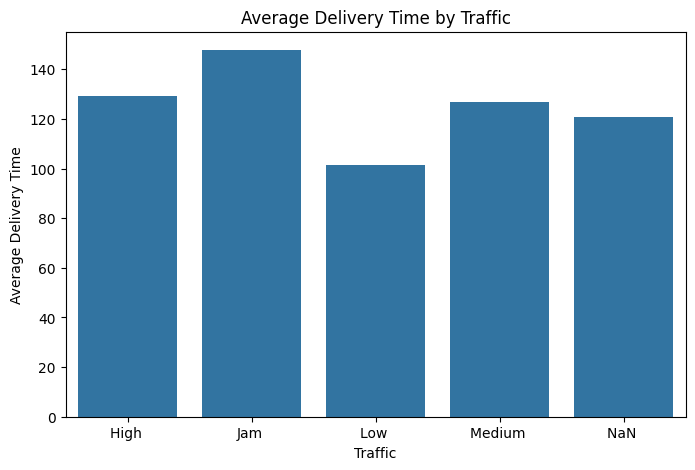

In [10]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Traffic", y="Delivery_Time", estimator=np.mean, errorbar=None)
plt.title("Average Delivery Time by Traffic")
plt.xlabel("Traffic")
plt.ylabel("Average Delivery Time")
plt.show()

**Penjelasan:**
Disini, dapat dilihat bahwa rata-rata waktu delivery itu paling tinggi terjadi ketika kondisi lalu lintas sedang macet dan rata-rata waktu tercepat dicapai ketika lalu lintas sedang lancar yang berarti hubungan antara delivery time dengan traffic bersifat linear.

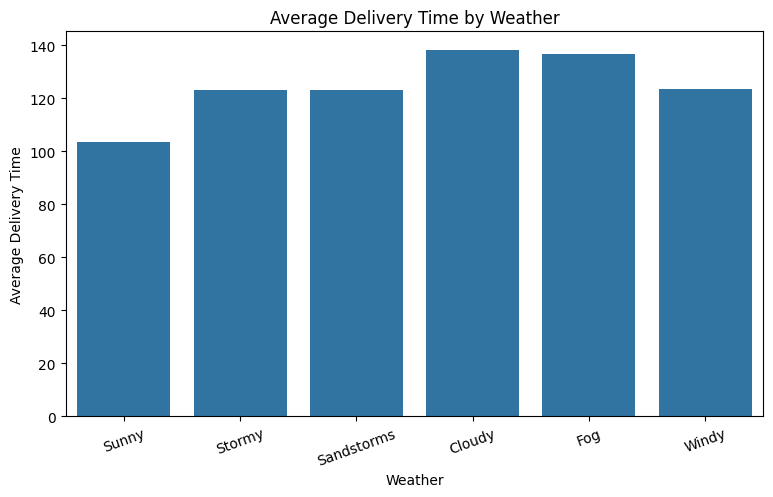

In [11]:
plt.figure(figsize=(9,5))
sns.barplot(data=df, x="Weather", y="Delivery_Time", estimator=np.mean, errorbar=None)
plt.title("Average Delivery Time by Weather")
plt.xlabel("Weather")
plt.ylabel("Average Delivery Time")
plt.xticks(rotation=20)
plt.show()

**Penjelasan:**
Disini, dapat dilihat bahwa rata-rata waktu delivery terlama terjadi pada cuaca berawan dan berkabut mungkin karena kondisi jalan yang susah dilewati akibat cuaca tersebut dan waktu tercepat dicapai ketika kondisi sunny.

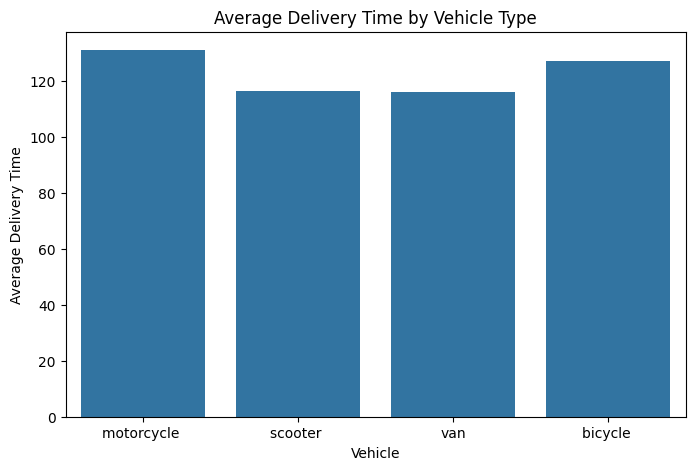

In [12]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Vehicle", y="Delivery_Time", estimator=np.mean, errorbar=None)
plt.title("Average Delivery Time by Vehicle Type")
plt.xlabel("Vehicle")
plt.ylabel("Average Delivery Time")
plt.show()

**Penjelasan:**
Disini dapat dilihat bahwa rata-rata waktu delivery yang dilakukan paling cepat dikirim dengan menggunakan scooter dan juga van sedangkan penggunaan sepeda motor dan sepeda membutuhkan waktu yang lebih lama.

b. Untuk klasifikasi dari 4 kolom yang saya pilih ini, kolom Traffic, Vehicle, dan Weather bertipe kategorikal sedangkan kolom distance bertipe numerik

In [13]:
print("Tipe data Traffic:", df["Traffic"].dtype)
print("Tipe data Weather:", df["Weather"].dtype)
print("Tipe data Vehicle:", df["Vehicle"].dtype)
print("Tipe data Distance_km:", df["Distance_km"].dtype)

Tipe data Traffic: object
Tipe data Weather: object
Tipe data Vehicle: object
Tipe data Distance_km: float64


In [14]:
print("Kategori Traffic:", df["Traffic"].unique())
print("Kategori Weather:", df["Weather"].unique())
print("Kategori Vehicle:", df["Vehicle"].unique())

Kategori Traffic: ['High ' 'Jam ' 'Low ' 'Medium ' 'NaN ']
Kategori Weather: ['Sunny' 'Stormy' 'Sandstorms' 'Cloudy' 'Fog' 'Windy' nan]
Kategori Vehicle: ['motorcycle ' 'scooter ' 'van' 'bicycle ']


**Penjelasan:**
- Traffic memiliki beberapa kategori yaitu High, Jam, Low, Medium, dan juga NaN yang berarti tidak diisi atau null value.
- Weather memiliki kategori yaitu Sunny, Stormy, Sandstorms, Cloudy, Fog, Windy, dan juga terdapat nan yang sama seperti kolom traffic
- Vehicle memiliki kategori yaitu motorcycle, scooter, van, dan bicycle

In [17]:
print(f"Range Jarak (km): {df["Distance_km"].min():.2f} sampai {df["Distance_km"].max():.2f}")

Range Jarak (km): 1.47 sampai 19692.67


**Penjelasan:**
Disini, Range dari jarak pengiriman itu sendiri memiliki rentang dari 1,47 km hingga 19692,67 km

c. Untuk menganalisis hubungan antara fitur yang dipilih dengan Delivery_Time, saya melakukan beberapa visualisasi. Scatter plot antara Distance_km dan Delivery_Time menunjukkan bahwa semakin jauh jarak pengiriman, semakin lama waktu pengiriman. Selain itu, boxplot antara Traffic dan Delivery_Time menunjukkan bahwa kondisi lalu lintas yang lebih padat memiliki median waktu pengiriman yang lebih tinggi. Visualisasi antara Weather dan Delivery_Time juga menunjukkan bahwa kondisi cuaca buruk cenderung meningkatkan waktu pengiriman. Oleh karena itu, ketiga variabel tersebut memiliki hubungan yang cukup jelas dengan Delivery_Time.

## 2. The Right Visualization?

You want to understand the relationship between traffic conditions (Traffic) and delivery time (Delivery Time) using the Amazon delivery dataset.

a. Create at least 3 visualizations to identify this relationship and explain why you chose those visualizations!

b. What insights can be obtained from these visualizations regarding the effect of traffic conditions on delivery time?

c. If you want to know the variability of delivery time for each traffic condition, what visual elements should you pay attention to on the graph?

a. Distance vs Delivery Time, Traffic vs Delivery Time, Weather vs Delivery Time

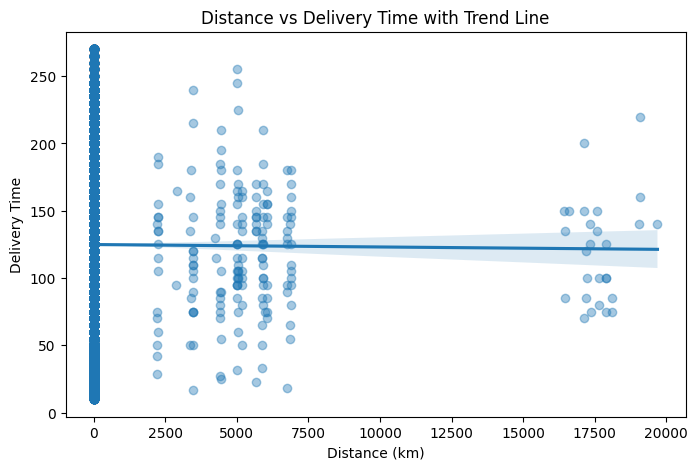

In [19]:
plt.figure(figsize=(8,5))
sns.regplot(data=df, x="Distance_km", y="Delivery_Time", scatter_kws={"alpha":0.4})
plt.title("Distance vs Delivery Time with Trend Line")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time")
plt.show()

**Penjelasan:** 
Saya melakukan visualisasi ini untuk melihat hubungan antara jarak yang ditempuh dengan waktu pengiriman dimana ternyata meskipun jaraknya tidak terlalu jauh, waktu pengiriman yang dihasilkan tidak selalu sama dimana dengan jarak yang hampir sama bisa lebih lama maupun lebih cepat

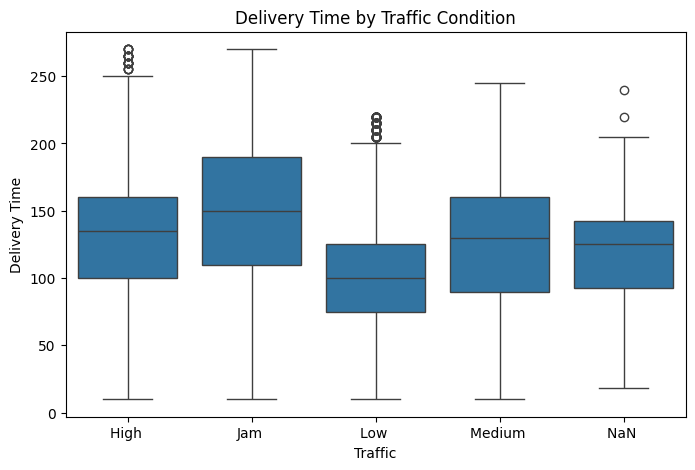

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Traffic", y="Delivery_Time")
plt.title("Delivery Time by Traffic Condition")
plt.xlabel("Traffic")
plt.ylabel("Delivery Time")
plt.show()

**Penjelasan:**
Disini saya melakukan visualisasi menggunakan boxplot untuk melihat hubungan kondisi lalu lintas dengan waktu pengiriman, dimana dapat dilihat bahwa waktu pengiriman yang paling lama itu terjadi ketika kondisi lalu lintas sedang macet atau Jam dengan interquartile range (IQR) sekitar 180-120 menit. Terlihat juga beberapa pengiriman yang dianggap sebagai outlier yang terjadi ketika lalu lintas sedang High dan juga low.

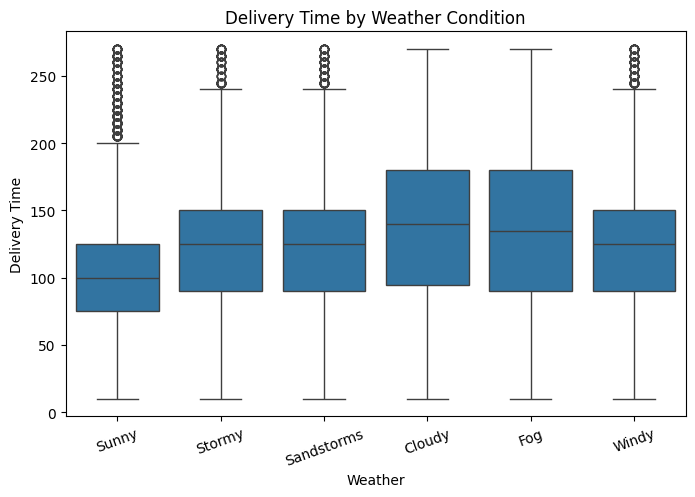

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Weather", y="Delivery_Time")
plt.title("Delivery Time by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Delivery Time")
plt.xticks(rotation=20)
plt.show()

**Penjelasan:**
Disini, saya melakukan visualisasi dengan menggunakan boxplot untuk melihat hubungan antara kondisi cuaca dan juga waktu pengiriman dimana kondisi cuaca yang berawan dan berkabut memiliki waktu pengantaran yang paling lama.

b. Insight yang saya dapatkan:
- Jarak pengiriman tidak terlalu berpengaruh pada waktu pengiriman karena dari scatter plot di atas, jarak yang dekat malah memiliki waktu pengiriman yang paling lama
- Kondisi lalu lintas berpengaruh pada waktu pengiriman dimana semakin macet kondisi lalu lintas maka waktunya juga semakin lama
- Kondisi cuaca yang berkabut dan berawan menyebabkan waktu delivery yang semakin lama
- Semakin cerah cuacanya, maka waktu pengiriman juga semakin cepat

c. Pada boxplot di atas, saya melihat bahwa variasi atau persebaran lamanya waktu pengiriman pada setiap kondisi lalu lintas dan cuaca disediakan oleh beberapa elemen visual pada grafik. Variasi data dapat dilihat dari kotak IQR dan panjang whiskers dimana box yang semakin besar juga memiliki arti bahwa waktu pengiriman juga semakin bervariasi pada kondisi tersebut. Di dalam box ini jgua dapat dilihat nilai median atau nilai tengah dari waktu pengiriman yang ada. Selain itu, terdapat juga outlier yang menunjukkan bahwa waktu pengiriman yang berbeda dengan data yang lain yang mungkin dipengaruhi oleh kondisi lainnya selain kondisi cuaca dan lalu lintas.

## 3. What can cause delivery time to be long or short?

As an analyst, you want to know what factors most influence delivery time.

a. What visualization is most appropriate for comparing delivery time by vehicle type? Include the visualization to support your argument!

b. If you want to see the relationship between traffic level and delivery time, what graph should be used?

c. Explain the operational insights that can be obtained from this analysis.

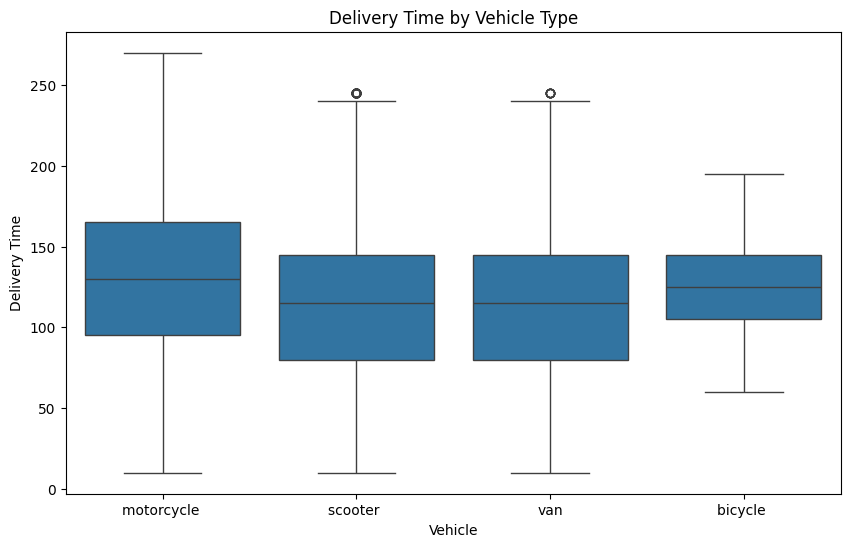

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Vehicle", y="Delivery_Time")
plt.title("Delivery Time by Vehicle Type")
plt.xlabel("Vehicle")
plt.ylabel("Delivery Time")
plt.show()

a. Saya menggunakan boxplot untuk melihat hubungan antara tipe kendaraan dengan waktu pengiriman karena dengan menggunakan boxplot, saya bisa melihat persebaran data yang ada, nilai outlier , nilai median dari waktu pengiriman, dan tipe kendaraan yang paling cepat dalam melakukan pengiriman. Selain itu, boxplot juga dapat digunakan untuk melakukan visualisasi pada fitur yang bersifat kategorikal.

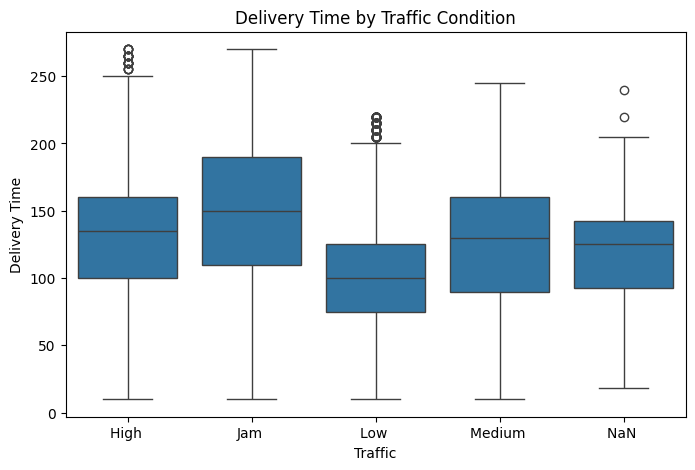

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Traffic", y="Delivery_Time")
plt.title("Delivery Time by Traffic Condition")
plt.xlabel("Traffic")
plt.ylabel("Delivery Time")
plt.show()

b. Mirip seperti visualisasi tipe kendaraan dan waktu pengiriman, saya juga menggunakan boxplot untuk visualisasi hubungan kondisi lalu lintas dengan waktu pengiriman karena saya dapat melihat persebaran data yang ada beserta kondisi lalu lintas yang memiliki waktu pengiriman tercepat dan juga kondisi lalu lintas ini berbentuk kategorikal.

c. Dari visualisasi hubungan antara jenis kendaran dengan waktu pengiriman dan kondisi lalu lintas dengan waktu pengiriman, beberapa operational insight yang dapat diimplementasikan oleh perusahaan yaitu:
- Memprioritaskan pengiriman pada kendaraan yang memiliki waktu pengiriman tercepat
- Menjadwalkan pengiriman yang lebih banyak dilakukan pada saat kondisi lalu lintas sedang lancar
- Memilih rute alternatif yang dapat digunakan ketika lalu lintas sedang macet

## 4. Your Boss Said: "Fix this bad graph, please."

Below is a poorly designed pie chart. Identify at least 3 problems with this visualization, then create a better version of this graph.

![Bad Graph](output.png)

**Jawaban:**
- Terlalu banyak ketogori, biasanya pie chart digunakan untuk proporsi kategori, tetapi pie chart di atas menampilkan distribusi dari data yang bersifat kontinu sehingga kategori yang terbentuk menjadi terlalu banyak.
- Area tiap daerah atau kategori memiliki perbedaan yang sangat kecil sehingga sangat susah untuk menentukan area yang paling dominan
- Label yang teralu banyak, biasanya pie chart hanya memiliki 1 label untuk setiap areanya akan tetapi pie chart di atas malah memiliki lebih dari 1 label seperti persentase dan waktu di tiap daerah.
- Semua nilai ditampilkan satu per satu, hal ini membuat kategori yang terbentuk menjadi sangat banyak yang seharusnya dikelompokkan menjadi beberapa kelompok saja

## 5. "Why does this graph hurt my eyes?"

Below is a visualization with terrible color choices. Identify at least 3 color-related problems and explain why they make the graph difficult to read. Then, recreate this graph with a proper color scheme.

![Bad Colors](output2.png)

**Jawaban:**
- Penggunaan warna yang terlalu terang dengan background warna putih sehingga lebih sulit untuk membaca setiap bar yang ada
- Penggunaan warna tulisan terang yang sangat susah dibaca karena hampir sama dengan warna background
- Terlalu banyak warna dalam satu grafik, warna yang digunakan tiap bar yang ada merupakan warna yang sangat berbeda dengan bar yang lain sehingga sangat susah untuk dibaca

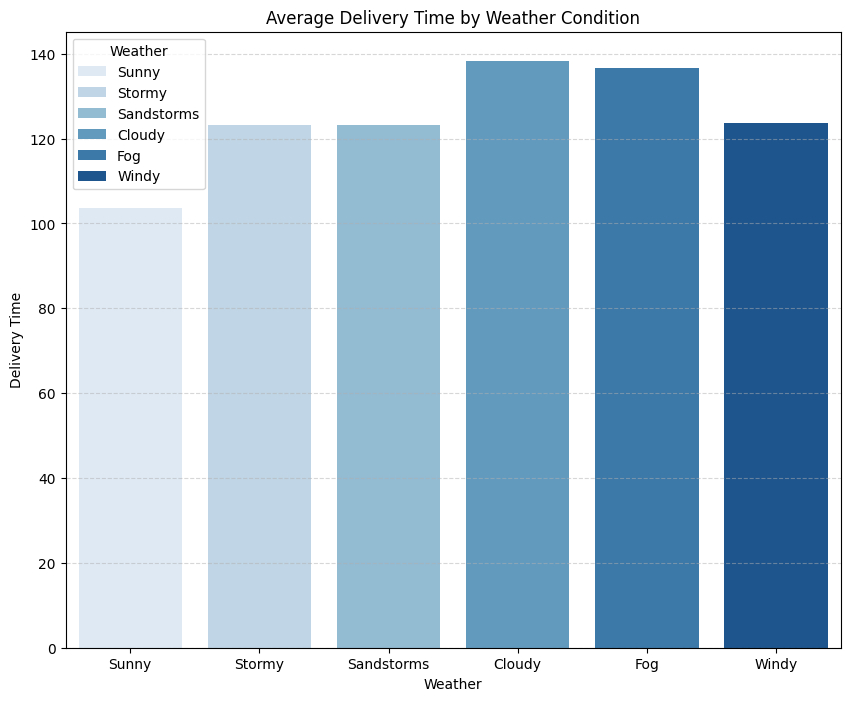

In [35]:
plt.figure(figsize=(10,8))
sns.barplot(data=df, x="Weather", y="Delivery_Time", palette="Blues", hue="Weather", errorbar=None)

plt.title("Average Delivery Time by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Delivery Time")

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Penjelasan:**
Disini saya memperbaiki grafik di atas menjadi lebih baik dengan perubahan yaitu:
- Warna dari tiap bar menggunakan warna biru dimana dimulai dari biru yang terang hingga ke biru yang lebih gelap
- Warna tulisan diganti menjadi warna hitam saja agar lebih mudah dibaca pada background putih
- Warna dari bar disesuaikan agar masih nyaman dilihat dan tidak terlalu mencolok

---

## Good Luck!

Remember: EDA is 80% staring at data and 20% making graphs that your boss will ask you to "fix" anyway.

*"The pain you feel today will be the strength you feel tomorrow... or at least that's what we tell ourselves when the data doesn't make sense."*

Happy analyzing!

> *"EDA is like therapy for your data — you uncover its issues, clean up its mess, and try to understand why it behaves the way it does. Good luck, and have fun with the pain!"*